In [1]:
import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import bisect
from scipy.spatial import cKDTree

import sys



# given plt file directory
# get the flame front point 
def read_get_flamex(d1):
    import yt
    import numpy as np
    import pandas as pd
    #load ds
    ds = yt.load(d1)
    ds.force_periodicity()
    # fields we will load per grid
    grad_keys = [
        ("boxlib", "Y(H2)_gradient_x"),
        ("boxlib", "Y(H2)_gradient_y"),
        ("boxlib", "Y(H2)_gradient_z"),
    ]
    Tkey = ("boxlib", "temp")
    
    # Collect chunks here
    chunks = []
    for g in ds.index.grids:
   
        if float(g.LeftEdge[0]) >= 0.07:
            continue
    
        # Pull minimal fields first (to build mask cheaply)
        x = g[("index", "x")].ndarray_view().ravel()
        T = g[Tkey].ndarray_view().ravel()
        dx = g[("index", "dx")].ndarray_view().ravel()
    
        mask = (T > 305.0) & (x < 0.07) & (dx<35e-6)
        if not np.any(mask):
            continue
    
        # Now pull only what you need (still per-grid, so small)
        y  = g[("index", "y")].ndarray_view().ravel()
        z  = g[("index", "z")].ndarray_view().ravel()
    
        data = {
            "x": x[mask],
            "y": y[mask],
            "z": z[mask],
            "T": T[mask],
            "gridsize": dx[mask],
        }
        chunks.append(pd.DataFrame(data))
    
    df_350 = pd.concat(chunks, ignore_index=True)
    
    #print(df_350['x'].min(),df_350['x'].max())
    x_cold_region = df_350['x'].min()
    idx_min = df_350['x'].idxmin()
    print(df_350[['x','y','z']].iloc[idx_min])
    

    return x_cold_region



def find_pts(df,x0,y0,z0,curr_dx):
    pts_good = []
    coord_dict = {}
    
    
    xbl, xbr = x0 - 4*curr_dx, x0 + 4*curr_dx
    ybl, ybr = y0 - 4*curr_dx, y0 + 4*curr_dx
    zbl, zbr = z0 - 4*curr_dx, z0 + 4*curr_dx
    #print(f' trying to find points for {x0},{y0},{z0}')
    # the 01 indiation of cubic
    coord_idx = [[-1,-1,-1], [-1,-1,1], [-1,1,-1],[-1,1,1],
                [1,-1,-1], [1,-1,1], [1,1,-1],[1,1,1], ]


    for ec in coord_idx:
        x_edge = xbr if ec[0] ==1 else xbl
        y_edge = ybr if ec[1] ==1 else ybl
        z_edge = zbr if ec[2] ==1 else zbl

        subxl, subxr = min(x_edge,x0), max(x_edge,x0)
        subyl, subyr = min(y_edge,y0), max(y_edge,y0)
        subzl, subzr = min(z_edge,z0), max(z_edge,z0)


        if subzl <0:
            subzl += curr_dx/2
            subzr += curr_dx/2

        if (subxl >0.07 ) or (subxr >0.07):
            subxl += 3*curr_dx
            subxr += 3*curr_dx

        
        temp_cut = df[ (df['x'] > subxl) &  (df['x'] <= subxr) & (df['y'] > subyl) &  (df['y'] <= subyr) & (df['z'] > subzl) &  (df['z'] <= subzr)]


        
        df_cut = temp_cut.copy()
        #
        if (df_cut.shape[0]==0):
            print(f'no point can be found for x:{subxl }:{subxr }, y: {subyl }:{subyr }, z:{subzl }:{subzr }')
        points = df_cut[['x','y','z']].to_numpy()
        tree = cKDTree(points)
        
        #print(f'subxl: {subxl}, subxr: {subxr}')
        #print(f'subyl: {subyl}, subyr: {subyr}')
        #print(f'subzl: {subzl}, subzr: {subzr}')
        #print(df_cut['x'].min(), df_cut['x'].max())
        query_point = np.array([x0, y0, z0])
        # index is the index of the original df
        # and this index need to be stored and used
        #dist, idx = tree.query(query_point)
        #print(f"for {ec} is nearest index is {idx} with distance {dist} x:{df_out['x'].loc[idx]}, y:{df_out['y'].loc[idx]}, z:{df_out['z'].loc[idx]}.")
        dist, i_local = tree.query(query_point)
        if(subxl>subxr):
            print('something wrong on x !')
            break

        if(subyl>subyr):
            print('something wrong on y !')
            break

        if(subzl>subzr):
            print('something wrong on z!')
            break
        
        idx_global = df_cut['global_index'].iloc[int(i_local)]
        
        #print(f'local index is {i_local} and global index is {idx_global}.')
        #print(f"xyz: {df[['x','y','z']].iloc[idx_global]}")
        
        pts_good.append(idx_global)
        coord_dict[tuple(ec)] = idx_global
        


    return pts_good, coord_dict


# get flame region cut df
def get_flame_cut(d1,Tcut:float=315,x_cold_region:float=0,max_resol=34.1e-6):
    import yt
    import numpy as np
    import pandas as pd
    #load ds
    ds = yt.load(d1)
    ds.force_periodicity()
    # add the 
    ds.add_gradient_fields(("boxlib", "Y(H2)"))

    half_grid = max_resol/2
    
    Tkey = ("boxlib", "temp")
    mass_fields = [f for f in ds.field_list if "Y(" in f[1]]
    # fields we will load per grid
    grad_keys = [
        ("boxlib", "Y(H2)_gradient_x"),
        ("boxlib", "Y(H2)_gradient_y"),
        ("boxlib", "Y(H2)_gradient_z"),
    ]
  

    # Collect chunks here
    chunks = []
    
    
    for g in ds.index.grids:
        # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    
        # Pull minimal fields first (to build mask cheaply)
        x = g[("index", "x")].ndarray_view().ravel()
        T = g[Tkey].ndarray_view().ravel()
        dx = g[("index", "dx")].ndarray_view().ravel()
    
        """
        Just cut the region at the boundary of isothermal wall x=0.07
        If need to find points of flame at isothermal wall, make sure set the value larger than 0.07 (e.g. x< 0.075)
        """
        #mask = (x>=x_cold_region) & (x < 0.075)
        mask = (x>=x_cold_region) & (x < 0.075) & (dx< max_resol*1.05 )
        if not np.any(mask):
            continue
    
        # Now pull only what you need (still per-grid, so small)
        y  = g[("index", "y")].ndarray_view().ravel()
        z  = g[("index", "z")].ndarray_view().ravel()
        #dx = g[("index", "dx")].ndarray_view().ravel()
    
        gh2x = g[grad_keys[0]].ndarray_view().ravel()
        gh2y = g[grad_keys[1]].ndarray_view().ravel()
        gh2z = g[grad_keys[2]].ndarray_view().ravel()
        gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

        #mask = (x>=x_cold_region) & (x < 0.075) & (dx< max_resol*1.05 )

        
        data = {
            "x": x[mask],
            "y": y[mask],
            "z": z[mask],
            "T": T[mask],
            "gridsize": dx[mask],
            "gh2x": gh2x[mask],
            "gh2y": gh2y[mask],
            "gh2z": gh2z[mask],
            "gh2mag": gh2mag[mask],
        }
            # mass fractions (only masked cells)
        for f in mass_fields:
            data[f[1]] = g[f].ndarray_view().ravel()[mask]
    
        chunks.append(pd.DataFrame(data))




    if len(chunks) == 0:
        raise RuntimeError("No cells found for (T>350) & (x<0.07).")

    df_cut = pd.concat(chunks, ignore_index=True)
    
    df_cut = df_cut[df_cut['gridsize']<35e-6].reset_index(drop=True)
    df_cut['global_index'] =df_cut.index
    min_idx = df_cut[df_cut['T']>Tcut]['x'].idxmin()
    #print(min_idx)

    df_cut['x_grid'] = round(df_cut['x']/half_grid)
    df_cut['y_grid'] = round(df_cut['y']/half_grid)
    df_cut['z_grid'] = round(df_cut['z']/half_grid)
    
    #return df_cut, [df_cut['x'].iloc[min_idx], df_cut['y'].iloc[min_idx], df_cut['z'].iloc[min_idx] ]
    return df_cut, min_idx


def find_pathline(df, x0,y0,z0,cutoff_value,max_length,curr_dx):
    pathline = []
    pathline_dict =[]
    find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx,pathline,pathline_dict)
    
    return pathline,pathline_dict




def find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx,pathline,pathline_dict):
    # if the line is long enough, then return
    if len(pathline)>=2:
        pt0 = pathline[0]
        ptlast = pathline[-1]
        distance = ((pt0[0] - ptlast[0] )**2  + (pt0[1] - ptlast[1]  )**2 + (pt0[2] - ptlast[2]  )**2 )**0.5
        if distance >= cutoff_value:
            return 
    if len(pathline_dict) >= max_length:
            return 

    temp_weight_dict = get_weight_w_point(df,x0,y0,z0,curr_dx)
    #print(temp_weight_dict)

    # make sure the indexes of pathline and pathline dict are aligned
    pathline.append([x0,y0,z0])
    pathline_dict.append(temp_weight_dict)


    # that's the c_i/ |c| part 
    x_dirc, y_dirc, z_dirc = 0,0,0
    next_dx  =  0
    for k,v in temp_weight_dict.items():
        x_dirc += (df['gh2x'].iloc[k] * v)
        y_dirc += (df['gh2y'].iloc[k] * v)
        z_dirc += (df['gh2z'].iloc[k] * v)
        #next_dx = max(next_dx, df['gridsize'].iloc[k])
    next_dx = curr_dx
    norm_dist = (x_dirc**2+ y_dirc**2+z_dirc**2)**0.5
    x_next = x0  - x_dirc/norm_dist * next_dx
    y_next = y0  - y_dirc/norm_dist * next_dx
    z_next = z0  - z_dirc/norm_dist * next_dx
    if z_next <=0:
        return
    #print(f'The next point is x: {x_next}, y: {y_next} , z: {z_next}')

    find_next_point_cubic(df,x_next,y_next,z_next,cutoff_value,max_length,next_dx,pathline,pathline_dict)
        
    return 

def get_weight_w_point(df0,x0,y0,z0,curr_dx):

    df =df0.copy()
    temp_ls, _ = find_pts(df,x0,y0,z0,curr_dx)
    
    temp_dist = []
    subdf = df[['x', 'y', 'z']].loc[temp_ls]
    #print(f'the length of subdf is {subdf.shape[0]}')
    minv = 1e-12
    currmin = 100
    for i in range(subdf.shape[0]):
        tx = subdf['x'].iloc[i]
        ty = subdf['y'].iloc[i]
        tz = subdf['z'].iloc[i]
        minxyz_pre = [(tx - x0  )**2, (ty - y0  )**2 , (tz- z0  )**2 ] 
        
        minxyz = [ x for x in minxyz_pre if x>0]
        minxyz.append(currmin)
        currmin = min(minxyz)
        #print(f'for current {tx}, {ty}, {tz}, the diff is {minxyz}')

    minv = min(1e-4, currmin/1000)

    

    #print(minv)
    
    for i in range(subdf.shape[0]):
        x_diff = subdf['x'].iloc[i] - x0 if (subdf['x'].iloc[i] - x0)!=0 else minv
        y_diff = subdf['y'].iloc[i] - y0 if (subdf['y'].iloc[i] - y0)!=0 else minv
        z_diff = subdf['z'].iloc[i] - z0 if (subdf['z'].iloc[i] - z0)!=0 else minv

        
        temp_dist.append( 1/( (x_diff)**2 +   (y_diff)**2 +( z_diff)**2) )

    sum_weight = sum(temp_dist)
    weight_dict = {}
    check_ttl=0

    # find way to 
    for i in range(subdf.shape[0]):
        if subdf.index[i] not in weight_dict:
            weight_dict[subdf.index[i]] = temp_dist[i] /  sum_weight
        else:
            weight_dict[subdf.index[i]] += temp_dist[i] /  sum_weight

    #print(check_ttl)
    return weight_dict


def get_T_Mass_from_list(df,pathline,pathline_dict):
    index_col = ['x', 'y', 'z']
    header_col = [ec for ec in df.columns if 'Y('  in ec ]
    header_col.append('T')
    header_col.extend( ['gh2x','gh2y', 'gh2z'])
    full_col = index_col+ header_col
    #final_df = pd.DataFrame(columns=full_col)
    # this list combined 2 items, [index, value]
    # then sort by index. 
    final_list = []
    for i in range(len(pathline_dict)):
        temp_dict = pathline_dict[i]
        temp_target_coord = pathline[i]
        
        temp_intp_list = []
        temp_intp_list.extend(pathline[i])
        temp_intp_weight = []
        #print(temp_dict)
        w=pd.Series(temp_dict, name="weight")
        temo_subdf = df[header_col].loc[w.index].copy()
        temo_subdf["weight"] = w
        #print(temo_subdf)
        #num_cols = df_selected.select_dtypes(include="number").columns
        df_weighted = temo_subdf[header_col].multiply(temo_subdf["weight"], axis=0)
        
        for i in range(len(header_col)):
            #print(df_weighted[header_col[i]])
            temp_intp_list.append(sum(df_weighted[header_col[i]]))
        final_list.append(temp_intp_list)
    
        
    return pd.DataFrame(final_list,columns = full_col)


def get_flame_cut_curv(d1,Tcut:float=305,x_cold_region:float=0,max_resol=34.1e-6):
    import yt
    import numpy as np
    import pandas as pd
    #load ds
    ds = yt.load(d1)
    ds.force_periodicity()
    # add the 
    ds.add_gradient_fields(("boxlib", "Y(H2)"))

    eps = 1e-12
    yh2_ub = 0.01304
    YH2_field = ("boxlib","Y(H2)")
    def _c(field, data):
        c = 1.0 - data[YH2_field] / yh2_ub
        return np.clip(c, 0.0, 1.0)
    
    ds.add_field(("boxlib","c"), function=_c, sampling_type="cell",
                 units="dimensionless", force_override=True)
    
    ds.add_gradient_fields(("boxlib","c"))

    half_cell = max_resol/2
    def _nx(field, data):
        gx = data[("boxlib","c_gradient_x")]
        g  = data[("boxlib","c_gradient_magnitude")]
        eps_u = data.ds.quan(1e-30, str(g.units))
        return gx / (g + eps_u)
    
    def _ny(field, data):
        gy = data[("boxlib","c_gradient_y")]
        g  = data[("boxlib","c_gradient_magnitude")]
        eps_u = data.ds.quan(1e-30, str(g.units))
        return gy / (g + eps_u)
    
    def _nz(field, data):
        gz = data[("boxlib","c_gradient_z")]
        g  = data[("boxlib","c_gradient_magnitude")]
        eps_u = data.ds.quan(1e-30, str(g.units))
        return gz / (g + eps_u)

    ds.add_field(("boxlib","nx"), function=_nx, sampling_type="cell",
                 units="dimensionless", force_override=True)
    ds.add_field(("boxlib","ny"), function=_ny, sampling_type="cell",
                 units="dimensionless", force_override=True)
    ds.add_field(("boxlib","nz"), function=_nz, sampling_type="cell",
                 units="dimensionless", force_override=True)

    ds.add_gradient_fields(("boxlib","nx"))
    ds.add_gradient_fields(("boxlib","ny"))
    ds.add_gradient_fields(("boxlib","nz"))
    
    def _kappa(field, data):
        return (data[("boxlib","nx_gradient_x")] +
                data[("boxlib","ny_gradient_y")] +
                data[("boxlib","nz_gradient_z")])
    
    ds.add_field(("boxlib","curvature"), function=_kappa, sampling_type="cell",
                 units="1/cm", force_override=True)   # unit label optional

    
    Tkey = ("boxlib", "temp")
    mass_fields = [f for f in ds.field_list if "Y(" in f[1]]
    # fields we will load per grid
    grad_keys = [
        ("boxlib", "Y(H2)_gradient_x"),
        ("boxlib", "Y(H2)_gradient_y"),
        ("boxlib", "Y(H2)_gradient_z"),
    ]
  

    # Collect chunks here
    chunks = []
    
    
    for g in ds.index.grids:
        # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    
        # Pull minimal fields first (to build mask cheaply)
        x = g[("index", "x")].ndarray_view().ravel()
        T = g[Tkey].ndarray_view().ravel()
        dx = g[("index", "dx")].ndarray_view().ravel()
    
        """
        Just cut the region at the boundary of isothermal wall x=0.07
        If need to find points of flame at isothermal wall, make sure set the value larger than 0.07 (e.g. x< 0.075)
        """
        mask = (x>=x_cold_region) & (x < 0.075) & (dx< max_resol*1.05)
        if not np.any(mask):
            continue
    
        # Now pull only what you need (still per-grid, so small)
        y  = g[("index", "y")].ndarray_view().ravel()
        z  = g[("index", "z")].ndarray_view().ravel()
        
        
        curv = g[('boxlib', 'curvature')].ndarray_view().ravel()
        
        gh2x = g[grad_keys[0]].ndarray_view().ravel()
        gh2y = g[grad_keys[1]].ndarray_view().ravel()
        gh2z = g[grad_keys[2]].ndarray_view().ravel()
        gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

        heat_release = g[('boxlib', 'HeatRelease')].ndarray_view().ravel()
        data = {
            "x": x[mask],
            "y": y[mask],
            "z": z[mask],
            "T": T[mask],
            "gridsize": dx[mask],
            "gh2x": gh2x[mask],
            "gh2y": gh2y[mask],
            "gh2z": gh2z[mask],
            "gh2mag": gh2mag[mask],
            "Q":heat_release[mask],
            "k":curv[mask],
        }
            # mass fractions (only masked cells)
        for f in mass_fields:
            data[f[1]] = g[f].ndarray_view().ravel()[mask]
    
        chunks.append(pd.DataFrame(data))




    if len(chunks) == 0:
        raise RuntimeError("No cells found for (T>350) & (x<0.07).")

    df_cut = pd.concat(chunks, ignore_index=True)
    

    df_cut['x_grid'] = round(df_cut['x']/(half_cell))
    df_cut['y_grid'] = round(df_cut['y']/(half_cell))
    df_cut['z_grid'] = round(df_cut['y']/(half_cell))
    
    
    #print(min_idx)
    #return df_cut, [df_cut['x'].iloc[min_idx], df_cut['y'].iloc[min_idx], df_cut['z'].iloc[min_idx] ]
    df_cut['global_index'] =df_cut.index
    min_idx = df_cut[df_cut['T']>Tcut]['x'].idxmin()
    return df_cut, min_idx


In [5]:
dr1 = '/media/u0890475/6f7f5b18-6951-4d23-9e1b-146d3d4c2671/SW_cache/amr3_fb_full_p40_v8/plt_20251120_amr3_p3p45_ct4/plt59000'
dr2 = '/media/u0890475/6f7f5b18-6951-4d23-9e1b-146d3d4c2671/SW_cache/amr3_fb_full_p40_v8/plt_20251120_amr3_p3p45_ct4/plt59250'
pt1 = read_get_flamex(dr1)
df1,min_idx1 = get_flame_cut_curv(dr1,303,pt1,34.18e-6)
#df1['grid_index'] = round(df1['y']/ (34.1e-6),3)
df1f = df1[df1['T']>=305].reset_index(drop=True).copy()
y_unique = set(df1f['y_grid'])                                                                                                                  
y_index =[]
for i in y_unique:
    temp_df = df1f[df1f['y_grid']==i].sort_values(by='x',ascending=True).reset_index(drop=True)
    y_index.append(temp_df['global_index'].iloc[0])

df_r1 = df1.iloc[y_index].sort_values(by='y').reset_index(drop=True)

# second plt
pt2 = read_get_flamex(dr2)
df2,min_idx2 = get_flame_cut_curv(dr2,303,pt2,34.18e-6)
df2f = df2[df2['T']>=305].reset_index(drop=True).copy()
y_unique = set(df2f['y_grid'])
y_index2 =[]
for i in y_unique:
    temp_df = df2f[df2f['y_grid']==i].sort_values(by='x',ascending=True).reset_index(drop=True)
    y_index2.append(temp_df['global_index'].iloc[0])

df_r2 = df2.iloc[y_index2].sort_values(by='y').reset_index(drop=True)


df_1ff = df_r1.sort_values(by='y_grid',ascending=True).reset_index(drop=True)
df_2ff = df_r2.sort_values(by='y_grid',ascending=True).reset_index(drop=True)

yt : [INFO     ] 2026-03-09 09:40:59,006 Parameters: current_time              = 0.169180000000018
yt : [INFO     ] 2026-03-09 09:40:59,006 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-09 09:40:59,006 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-09 09:40:59,007 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]
yt : [INFO     ] 2026-03-09 09:41:29,242 Parameters: current_time              = 0.169180000000018
yt : [INFO     ] 2026-03-09 09:41:29,242 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-09 09:41:29,242 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-09 09:41:29,242 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


x    0.066052
y    0.006853
z    0.000222
Name: 36619, dtype: float64


yt : [INFO     ] 2026-03-09 09:42:08,325 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-03-09 09:42:08,325 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-09 09:42:08,325 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-09 09:42:08,325 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]
yt : [INFO     ] 2026-03-09 09:42:30,619 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-03-09 09:42:30,619 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-03-09 09:42:30,619 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-09 09:42:30,619 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


x    0.065540
y    0.006819
z    0.000188
Name: 34455, dtype: float64


In [13]:
df2[ (df1['x'] == 0.065540 ) & (df2['y'] == 0.006819 )  & (df2['z'] == 0.000188 )]

,x,y,z,T,gridsize,gh2x,gh2y,gh2z,gh2mag,Q,...,Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH),x_grid,y_grid,z_grid,global_index


In [15]:
y_forward =[]
y_backward = []
y_stay=[]
y_sign =[]
import matplotlib.pyplot as plt
import math
import numpy as np

x_coord = []
y_coord = []
curv = []

for i in range(df_1ff.shape[0]):
    #curr_sign =0
    if(df_2ff['x'].iloc[i] > df_1ff['x'].iloc[i]  ):
        y_sign.append(1)
        #print(f' point {i} is moving forward ')
        y_backward.append( df_2ff['global_index'].iloc[i] )
        curr_sign =1
    
    elif (df_2ff['x'].iloc[i] < df_1ff['x'].iloc[i] ):
        #print(f' point {i} is moving backward ')
        y_sign.append(-1)
        curr_sign =-1
        y_forward.append( df_2ff['global_index'].iloc[i]    )
    else:
        y_sign.append(0)
        curr_sign =0
        #print(f' point {i} is staying ')
        y_stay.append( df_2ff['global_index'].iloc[i]    )

df_cols = df1.columns
df_2ff['movement'] = y_sign
#df_y_fw = pd.DataFrame(np.vstack(y_forward),columns= list(df_cols)  )
#df_y_bw = pd.DataFrame(np.vstack(y_backward),columns=list(df_cols)  )
#df_y_st = pd.DataFrame(np.vstack(y_stay),columns= list(df_cols)   )

df_y_fw = df2.iloc[y_forward]
df_y_bw = df2.iloc[y_backward]
df_y_st = df2.iloc[y_stay]


In [49]:
#df_y_fw.to_csv('y_forward.csv',index=False)
#df_y_bw.to_csv('y_backward.csv',index=False)
#df_y_st.to_csv('y_stable.csv',index=False)

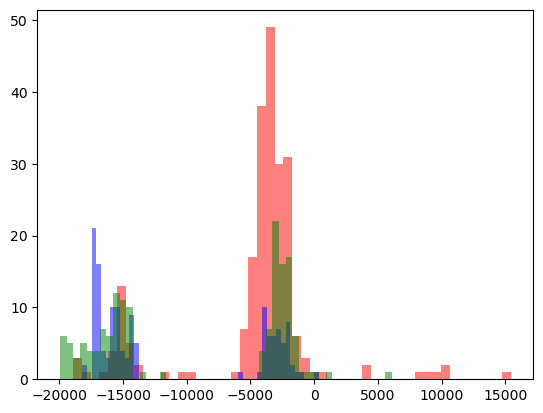

In [69]:
import matplotlib.pyplot as plt
plt.hist(df_y_fw['k'] ,  bins= 50, color='red', alpha=0.5, label='forward' )
plt.hist(df_y_st['k'] ,  bins= 50, color='blue', alpha=0.5, label='stable')
plt.hist(df_y_bw['k'] ,  bins= 50, color='green', alpha=0.5, label='backward' )
plt.show()

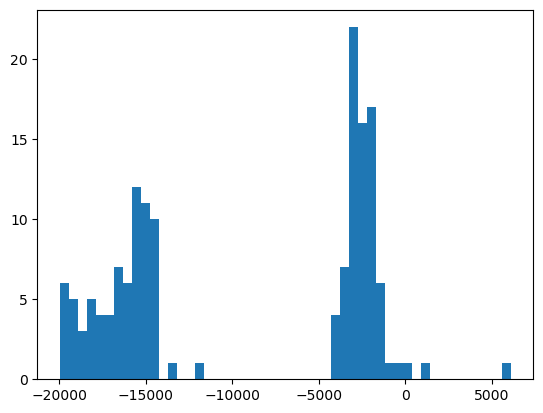

In [65]:

plt.show()

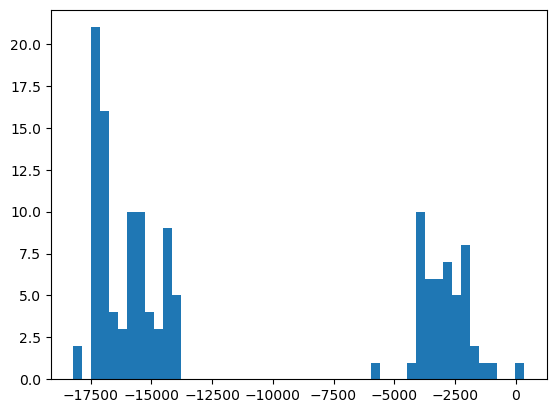

In [67]:

plt.show()

/tmp/ipykernel_9129/2711888508.py:45: UserWarning: Adding colorbar to a different Figure <Figure size 2400x1800 with 2 Axes> than <Figure size 2400x1800 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, ax=ax, label='curvature')


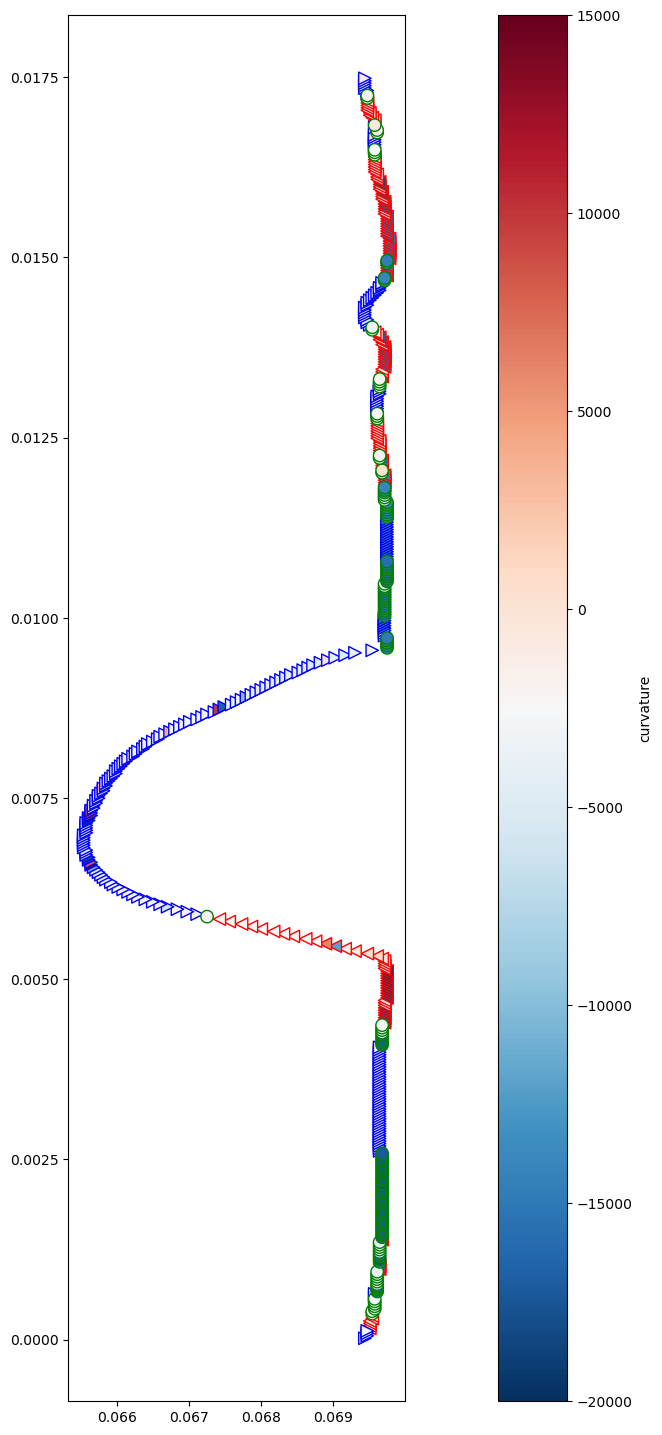

In [83]:
marker_list = []
for i in range(len(y_sign)):
    match y_sign[i]:
        case 1: 
            marker_list.append("<")
        case -1:
            marker_list.append(">")
        case 0:
            marker_list.append("s")


import numpy as np
import matplotlib.pyplot as plt





x = np.asarray(df_2ff['x'])
y = np.asarray(df_2ff['y'])
k = np.asarray(df_2ff['k'])
m = np.asarray(y_sign)

mask_f = (m == 1)
mask_b = (m == -1)
mask_s = (m == 0)

fig, ax = plt.subplots(figsize=(24, 18))
ax.set_aspect('equal', adjustable='box')
vmin = -20000
vmax = 15000

# dummy scatter for colorbar
#sc = ax.scatter(x, y, c=k, cmap='RdBu_r', vmin=vmin, vmax=vmax, s=1)

ax.scatter(x[mask_f], y[mask_f], c=k[mask_f], cmap='RdBu_r',
           vmin=vmin, vmax=vmax, marker='<', s=80, edgecolors='red')

ax.scatter(x[mask_b], y[mask_b], c=k[mask_b], cmap='RdBu_r',
           vmin=vmin, vmax=vmax, marker='>', s=80,  edgecolors='blue')

ax.scatter(x[mask_s], y[mask_s], c=k[mask_s], cmap='RdBu_r',
           vmin=vmin, vmax=vmax, marker='o', s=80,  edgecolors='green')

plt.colorbar(sc, ax=ax, label='curvature')


plt.show()

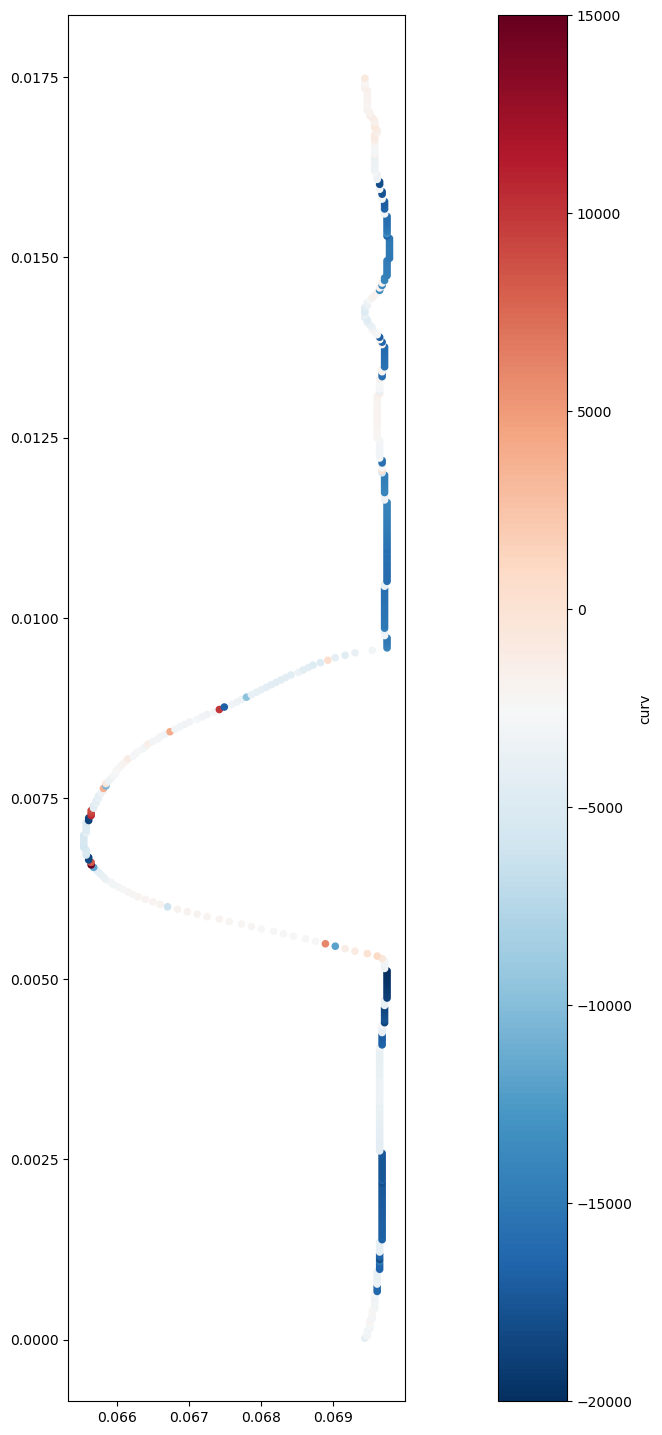

In [19]:
import numpy as np
import matplotlib.pyplot as plt





x = np.asarray(x_coord)
y = np.asarray(y_coord)
k = np.asarray(curv)
m = np.asarray(y_sign)

vmax = np.max(np.abs(k))
vmin = -vmax

fig, ax = plt.subplots(figsize=(24, 18))
ax.set_aspect('equal', adjustable='box')
# color by curvature
sc = ax.scatter(
    df_2ff['x'],
    df_2ff['y'],
    c=df_2ff['k'],
    cmap='RdBu_r',
    vmin=-20000,
    vmax=15000,
    s=20
)

plt.colorbar(sc, ax=ax, label='curv')

plt.show()

In [37]:
np.array(df_2ff['x'])[mask_b]

array([], shape=(0, 512), dtype=float64)

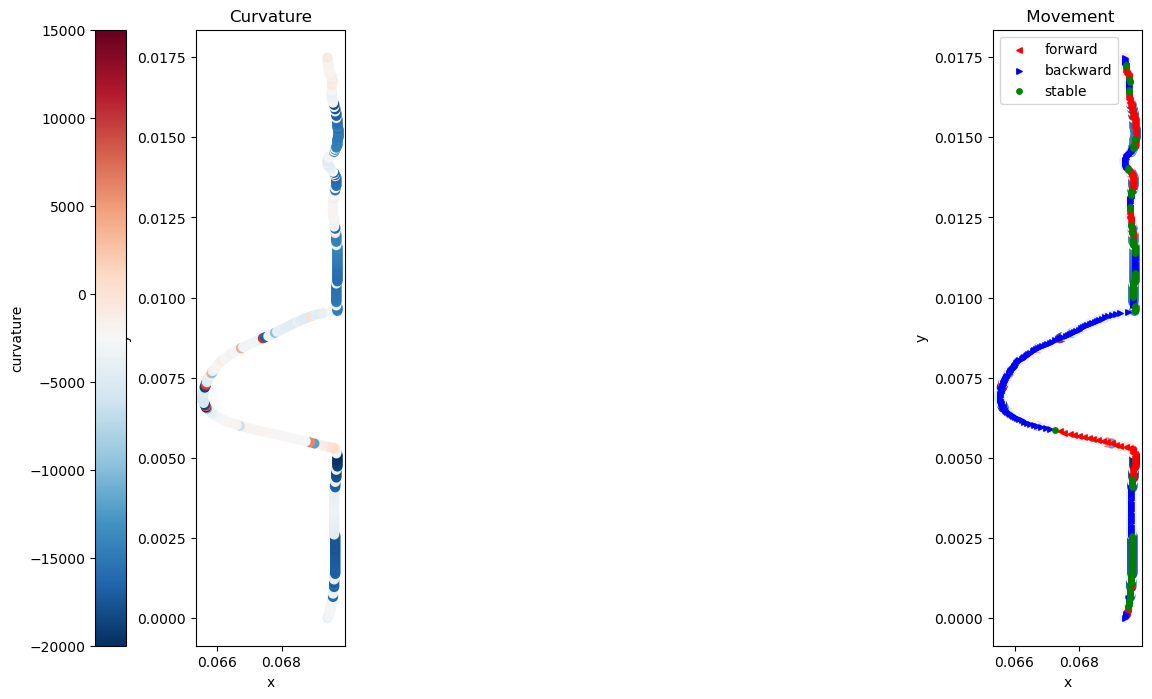

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# -----------------------
# LEFT: curvature only
# -----------------------
sc1 = ax[0].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=40
)

ax[0].set_title("Curvature")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

# -----------------------
# RIGHT: curvature + movement
# -----------------------
sc2 = ax[1].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=40
)

# overlay movement markers
ax[1].scatter(x[mask_f], y[mask_f], marker='<', color='red', s=15, label='forward')
ax[1].scatter(x[mask_b], y[mask_b], marker='>', color='blue', s=15, label='backward')
ax[1].scatter(x[mask_s], y[mask_s], marker='o', color='green',s=15, label='stable')

ax[1].set_title(" Movement")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()

# shared colorbar
fig.colorbar(sc1, ax=ax[0], label='curvature',location='left')

plt.show()

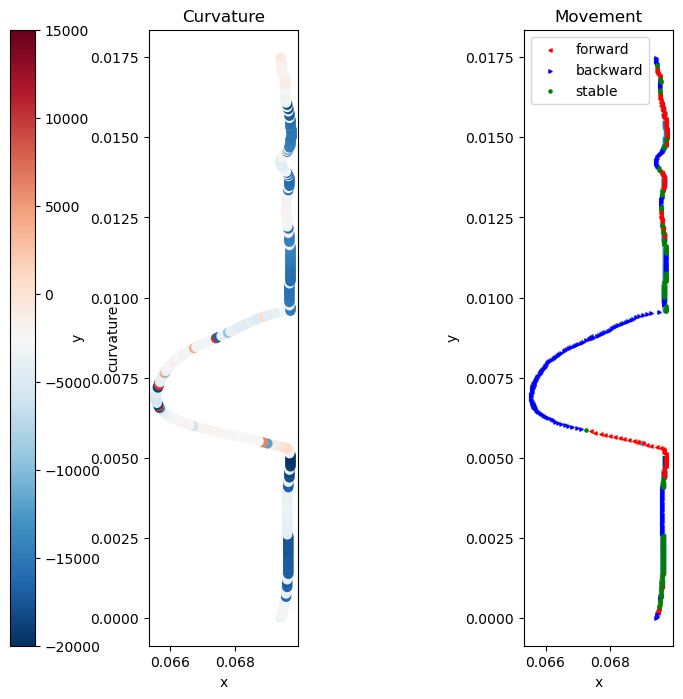

In [115]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(1, 3, width_ratios=[0.10, 1.5, 1.5], wspace=0.01)

cax = fig.add_subplot(gs[0])   # colorbar axis
ax0 = fig.add_subplot(gs[1])
ax1 = fig.add_subplot(gs[2])

ax = [ax0, ax1]

# -----------------------
# LEFT: curvature only
# -----------------------
sc1 = ax[0].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=40
)

ax[0].set_title("Curvature")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

# -----------------------
# RIGHT: curvature + movement
# -----------------------
sc2 = ax[1].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=10
)

# overlay movement markers
ax[1].scatter(x[mask_f], y[mask_f], marker='<', color='red', s=5, label='forward')
ax[1].scatter(x[mask_b], y[mask_b], marker='>', color='blue', s=5, label='backward')
ax[1].scatter(x[mask_s], y[mask_s], marker='o', color='green', s=5, label='stable')

ax[1].set_title("Movement")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()

# colorbar in dedicated axis on the far left
cbar = fig.colorbar(sc1, cax=cax)
cbar.set_label('curvature')

plt.show()

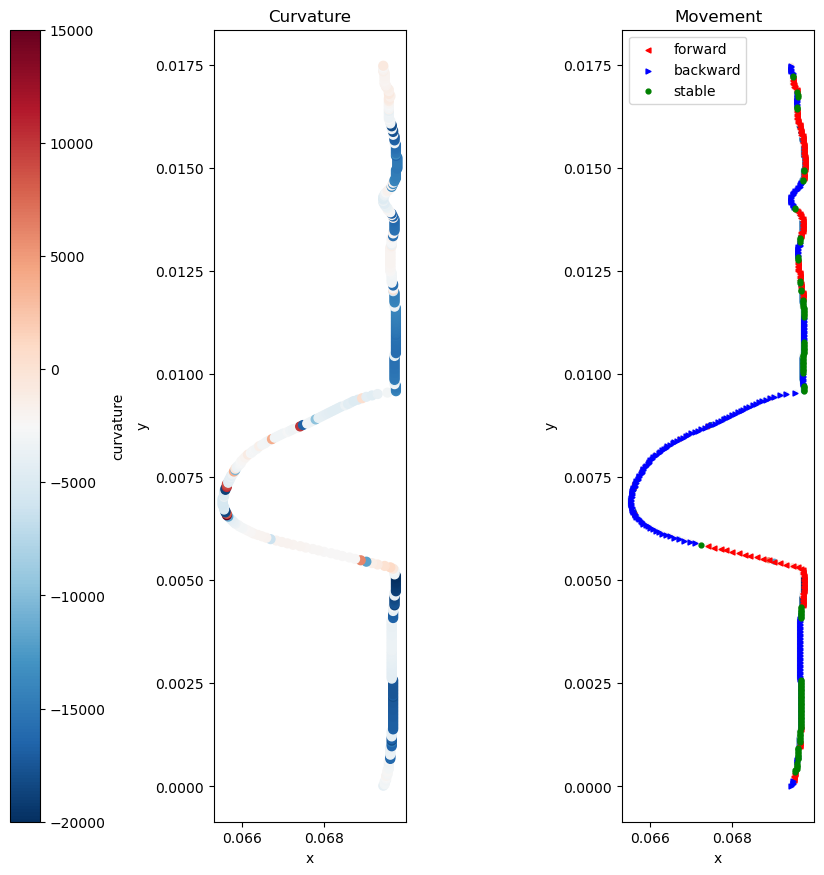

In [129]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 12))

# [left, bottom, width, height]
cax  = fig.add_axes([0.06, 0.17, 0.025, 0.66])   # colorbar
ax0  = fig.add_axes([0.12, 0.17, 0.38, 0.66])    # left plot
ax1  = fig.add_axes([0.46, 0.17, 0.38, 0.66])    # right plot

ax = [ax0, ax1]

# -----------------------
# LEFT: curvature only
# -----------------------
sc1 = ax[0].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=40
)

ax[0].set_title("Curvature")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

# -----------------------
# RIGHT: curvature + movement
# -----------------------
sc2 = ax[1].scatter(
    x, y,
    c=k,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    s=12
)

ax[1].scatter(x[mask_f], y[mask_f], marker='<', color='red',   s=12, label='forward')
ax[1].scatter(x[mask_b], y[mask_b], marker='>', color='blue',  s=12, label='backward')
ax[1].scatter(x[mask_s], y[mask_s], marker='o', color='green', s=12, label='stable')

ax[1].set_title("Movement")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()

cbar = fig.colorbar(sc1, cax=cax)
cbar.set_label("curvature")
plt.savefig('flamefront_curvature_movement.png',dpi=600)
plt.show()

In [137]:
pts2_t305 = df2[df2['T']>305]['x'].idxmin()
print(df2['z'].iloc[pts2_t305])

0.00018798828125


In [165]:
df2_ff =df2[(df2['z']==0.00018798828125)&(df2['T']>305)]
y_set = set(df2_ff['y'])
y_index =[]
for i in y_set:
    temp_df = df2_ff[df2_ff['y'] ==i]
    temp_idx =  df2['global_index'].iloc[temp_df['x'].idxmin()]
    y_index.append(temp_idx)

df2_xfront = df2.iloc[y_index]

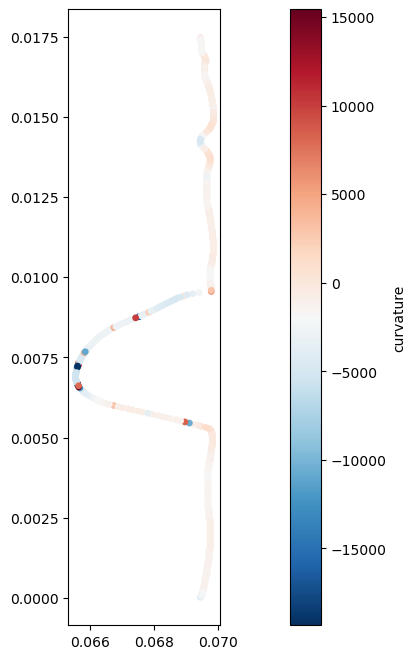

In [175]:
fig, ax = plt.subplots( figsize=(18, 8))
plt.scatter(df2_xfront['x'],df2_xfront['y'],c=df2_xfront['k'],cmap='RdBu_r',s=15)
ax.set_aspect('equal')
plt.colorbar( ax=ax, label='curvature')
plt.show()

In [163]:


df2_xfront 

,x,y,z,T,gridsize,gh2x,gh2y,gh2z,gh2mag,Q,...,Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH),x_grid,y_grid,z_grid,global_index
101,0.06554,0.000427,0.000188,298.000225,0.000034,-2.681048e-09,-1.248196e-09,2.368978e-09,3.789204e-09,0.086317,...,4.502825e-16,4.072686e-14,0.756999,5.008469e-24,0.229961,-1.290966e-22,3835.0,25.0,25.0,101
813,0.06554,0.001282,0.000188,298.000203,0.000034,-1.049784e-08,-7.267147e-10,1.701346e-08,2.000477e-08,0.006879,...,4.045293e-18,-2.314011e-14,0.756999,2.442042e-22,0.229961,-1.642118e-22,3835.0,75.0,75.0,813
1013,0.06554,0.002136,0.000188,298.000143,0.000034,-1.499669e-08,-1.414833e-10,4.134361e-08,4.397971e-08,-0.210371,...,6.828292e-18,-4.447154e-14,0.756999,6.049369e-21,0.229961,-1.512211e-22,3835.0,125.0,125.0,1013
142013,0.06554,0.002991,0.000188,298.000195,0.000034,-2.165482e-06,-1.691526e-06,3.583174e-06,4.515497e-06,-0.119797,...,1.770024e-12,5.464273e-13,0.756999,2.042606e-17,0.229961,3.002008e-20,3835.0,175.0,175.0,142013
142725,0.06554,0.003845,0.000188,298.000197,0.000034,-3.636284e-05,-4.717799e-06,4.014694e-05,5.437178e-05,-0.202265,...,3.090779e-09,5.782234e-10,0.756999,1.522241e-15,0.229961,2.312303e-18,3835.0,225.0,225.0,142725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851733,0.06554,0.014304,0.000188,298.000221,0.000034,-4.916956e-12,1.080025e-12,3.893774e-12,6.364306e-12,-0.021038,...,4.977207e-21,6.699533e-16,0.756999,-3.425300e-25,0.229961,-1.427687e-22,3835.0,837.0,837.0,851733
851933,0.06554,0.015159,0.000188,298.000190,0.000034,-2.700062e-12,1.108447e-12,2.842171e-13,2.932536e-12,-0.124715,...,2.177557e-21,-7.514299e-14,0.756999,-9.835302e-24,0.229961,-1.576740e-22,3835.0,887.0,887.0,851933
709237,0.06554,0.011433,0.000188,298.000196,0.000034,-5.307930e-08,-5.886022e-09,8.023730e-08,9.638507e-08,0.053753,...,6.484351e-21,-5.050066e-14,0.756999,9.906281e-22,0.229961,-1.656710e-22,3835.0,669.0,669.0,709237
850949,0.06554,0.013142,0.000188,298.000177,0.000034,-2.984279e-12,3.808509e-12,7.304379e-12,8.761542e-12,-0.104048,...,2.265842e-21,-1.415296e-14,0.756999,-5.967767e-25,0.229961,-1.503838e-22,3835.0,769.0,769.0,850949
